In [5]:
%pip install matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


d:\AI Data Science and MERN\Projects\Laptop-Price\backend\notebooks\data_cleaning
✅ df assigned successfully!
  device_type     brand              model  release_year       os form_factor  \
0     Desktop   Samsung  Samsung Forge XDI          2022  Windows         ATX   
1      Laptop   Samsung    Samsung Pro KM8          2022  Windows  Mainstream   
2     Desktop    Lenovo   Lenovo Strix BIE          2024    macOS         SFF   
3     Desktop      Dell      Dell Cube AXR          2024  Windows         ATX   
4      Laptop  Gigabyte   Gigabyte Pro IX1          2024    Linux      Gaming   

  cpu_brand         cpu_model  cpu_tier  cpu_cores  ...  resolution  \
0     Intel    Intel i5-11129         3         12  ...   2560x1440   
1     Intel    Intel i7-11114         4         12  ...   1920x1080   
2       AMD  AMD Ryzen 5 5168         2          8  ...   3440x1440   
3       AMD  AMD Ryzen 5 7550         2          6  ...   3440x1440   
4       AMD  AMD Ryzen 7 6230         5         

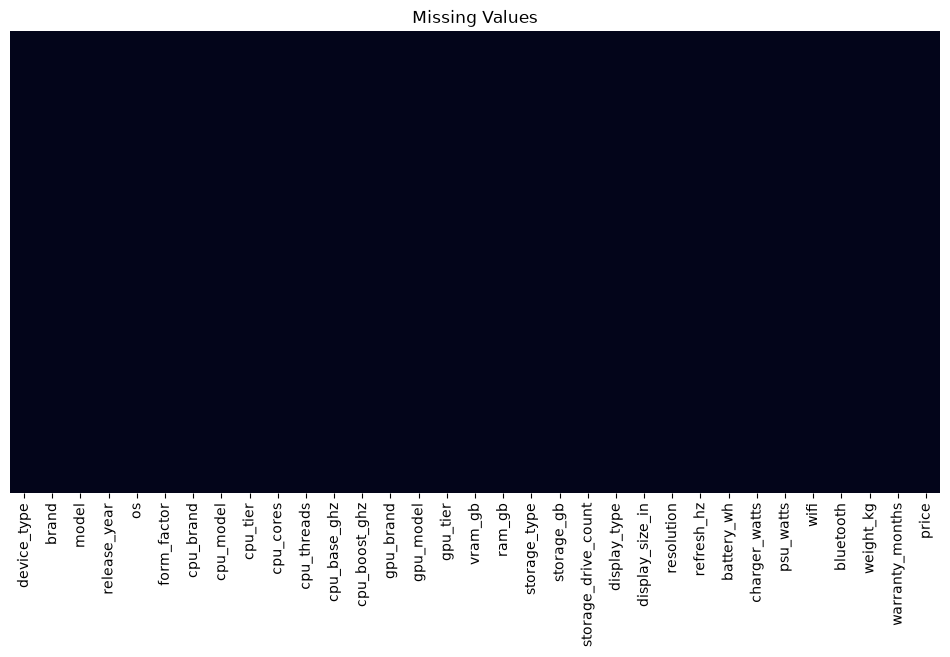

Duplicate Rows : 0
(100000, 33)
count    100000.000000
mean       1928.764220
std         580.492689
min         372.990000
25%        1503.990000
50%        1863.990000
75%        2287.990000
max       10984.990000
Name: price, dtype: float64


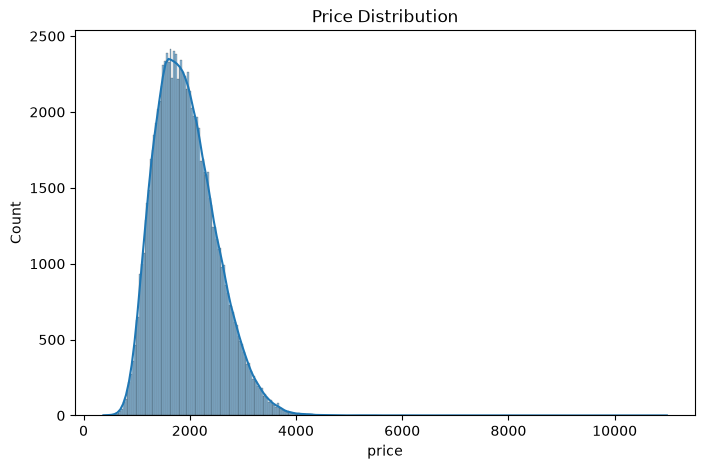

Numerical Features
['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'storage_drive_count', 'display_size_in', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'bluetooth', 'weight_kg', 'warranty_months', 'price']

Categorical Features
['device_type', 'brand', 'model', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'gpu_brand', 'gpu_model', 'storage_type', 'display_type', 'resolution', 'wifi']
device_type
device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64

brand
brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64

model
model
ASUS Slim R6S         3
Acer Creator 3U0      3
HP Creator R41        3
Samsung Pro HRZ       3
Lenovo Think 0V5      3
                     ..
ASUS Pro ZWL          1
Lenovo Stealth 014    1

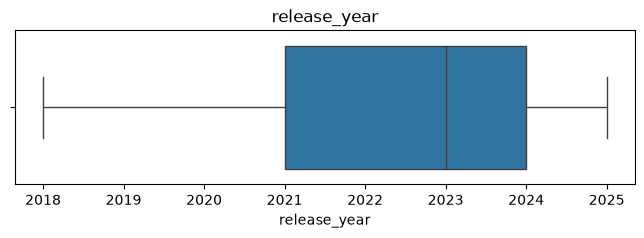

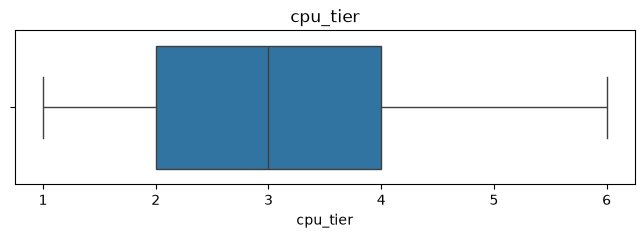

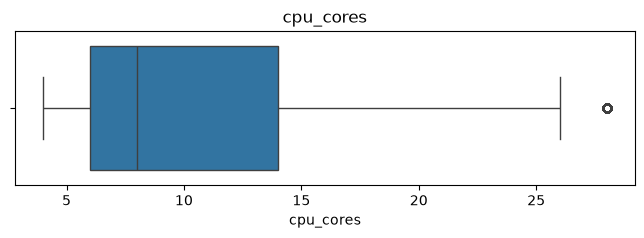

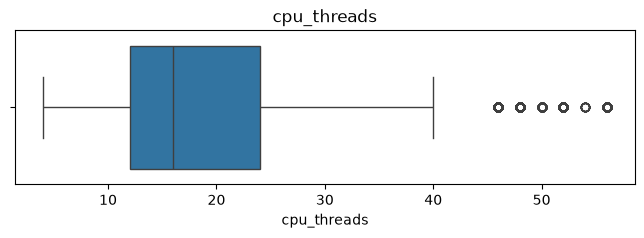

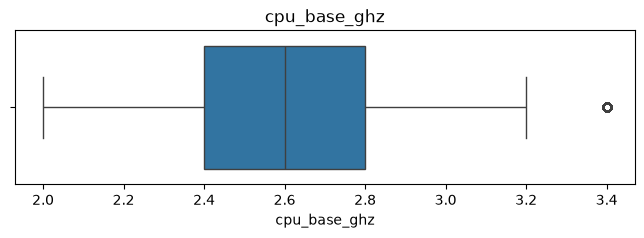

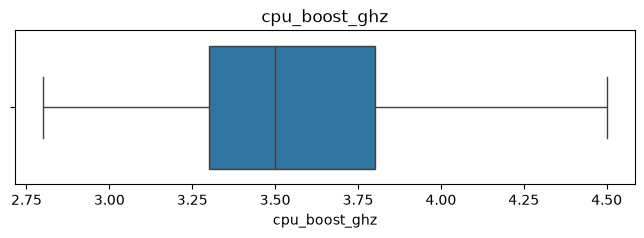

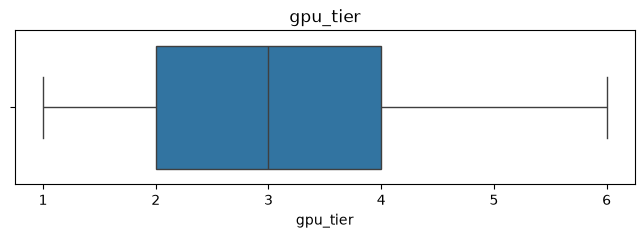

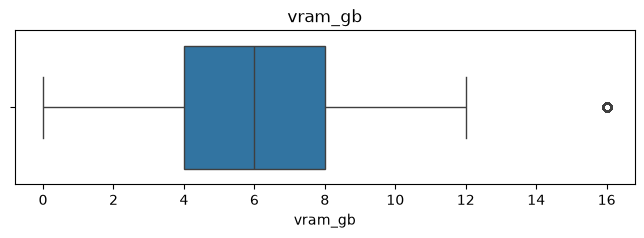

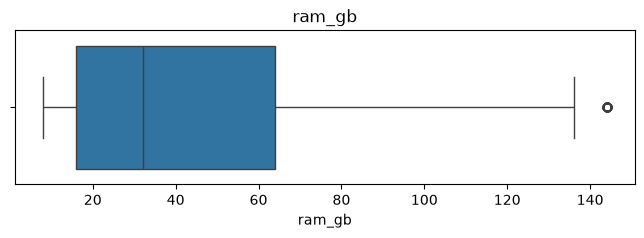

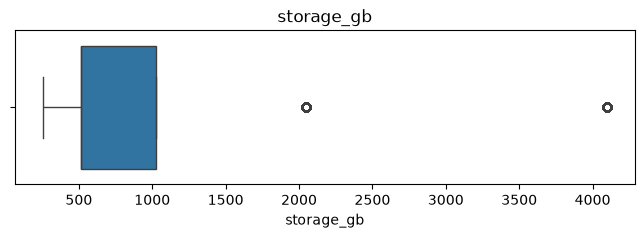

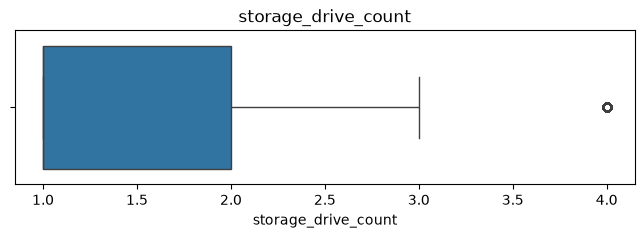

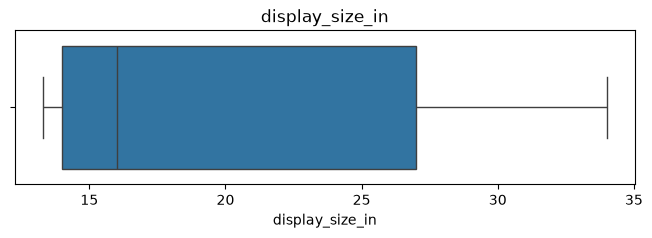

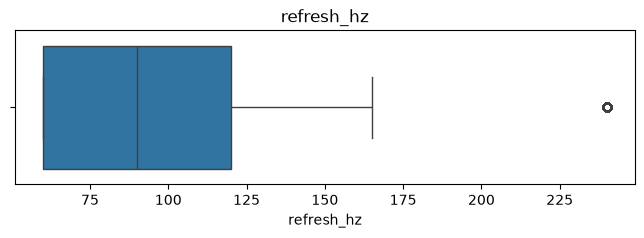

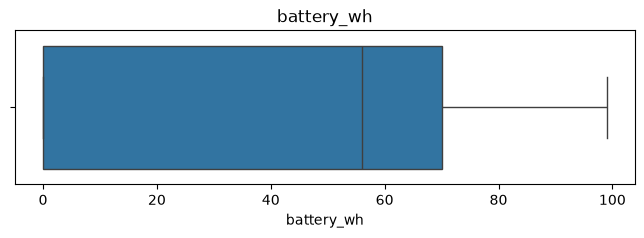

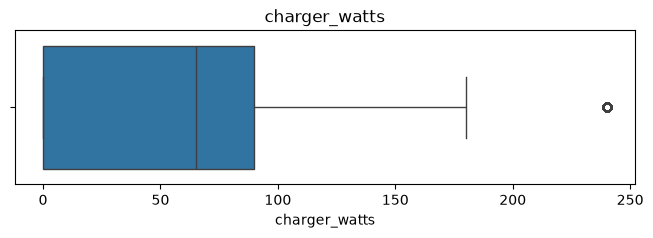

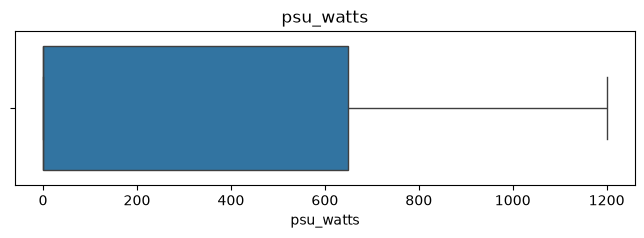

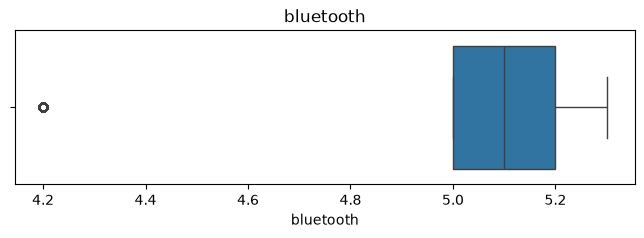

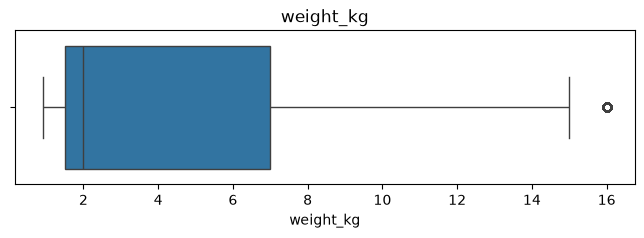

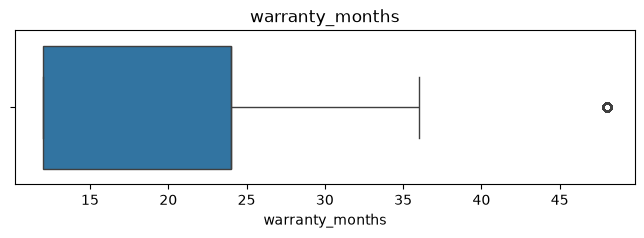

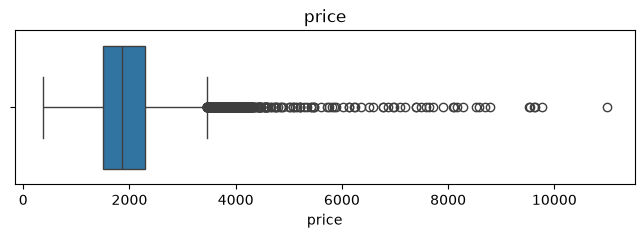

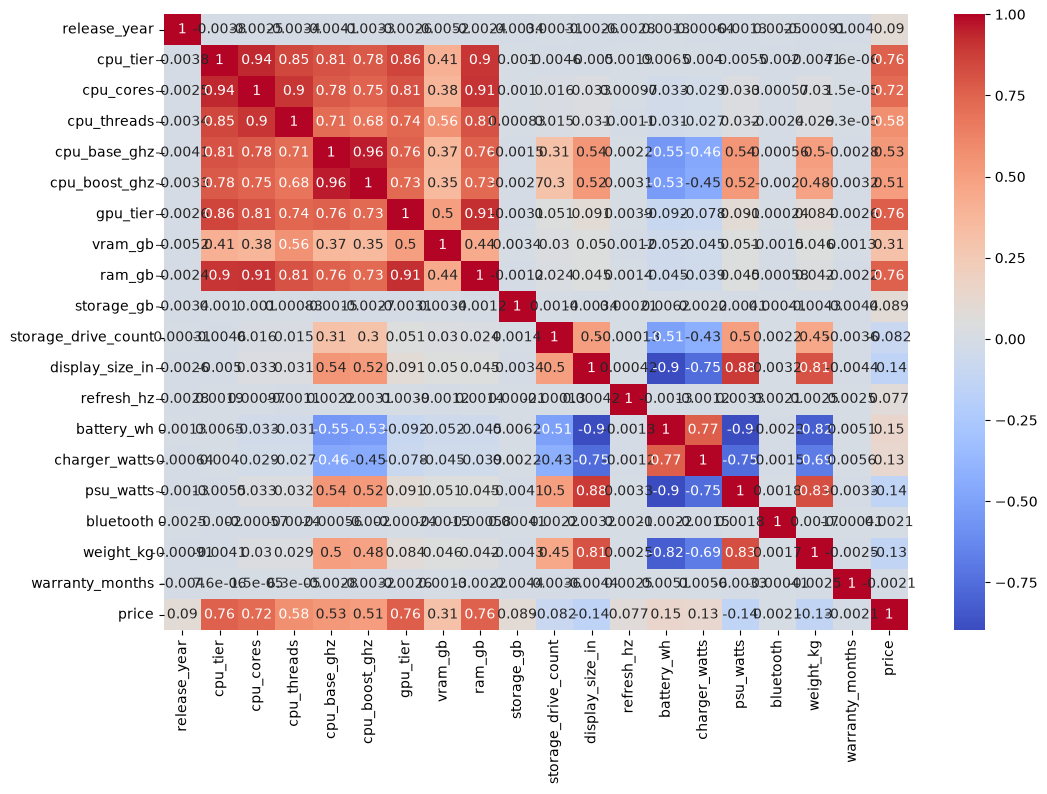

(100000, 33)
device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64
0
Dataset Saved Successfully


In [6]:
# from src.utils.paths import CLEANED_DATA, TRAIN_FEATURES, PROCESSED_DIR, FEATURES_DIR
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")
# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", 200)
# plt.style.use("ggplot")

current_notebook_dir = Path.cwd()
project_root = current_notebook_dir.parent.parent

print(current_notebook_dir)
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
Laptop_output_csv_path = processed_dir / "laptop_price_cleaned.csv"
computer_output_csv_path = processed_dir / "computer_prices_all_cleaned.csv"

csv_path = project_root / "data" / "raw" / "laptop_price.csv"
csv_computer= project_root / "data" / "raw" / "computer_prices_all.csv"

try:
    df = pd.read_csv(csv_computer, encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_computer, encoding="latin-1")

print("✅ df assigned successfully!")
print(df.head())
print("="*50)
# print(df["cpu_model"].sample(30, random_state=42).tolist())
# print("="*50)
print(f"📊 Dataset Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())
print("="*50)
print(f"Data types:\n{df.dtypes}")

#Checking for missing values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing.sort_values(
    by="Percentage",
    ascending=False
)

print("\nMissing Values:")
print(missing)

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()

# Duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

df = df.drop_duplicates()

print(df.shape)

# Check Target Variable

TARGET = "price"

print(df[TARGET].describe()) #df[TARGET].describe()

plt.figure(figsize=(8,5))

sns.histplot(
    df[TARGET],
    kde=True
)

plt.title("Price Distribution")
plt.show()

#  Separate Numerical & Categorical Features
numerical_features = df.select_dtypes( include=["int64","float64"]).columns.tolist()

categorical_features = df.select_dtypes(include="object").columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

# Check Unique Values

for col in categorical_features:

    print("="*60)
    print(col)
    print("="*60)

    print(df[col].value_counts())

    print()
    
# Remove Extra Spaces

for col in categorical_features:

    df[col] = ( df[col].astype(str).str.strip())
    
# Standardize Text
for col in categorical_features:
    df[col] = df[col].str.title()

# Check Impossible Values

for col in numerical_features:

    print(col)

    print(df[col].min())

    print(df[col].max())

    print()
    
#Check Outliers
for col in numerical_features:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()
# Check Correlation
plt.figure(figsize=(12,8))

corr = df[numerical_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

print(df.shape)

print(df.isnull().sum())

print(df.duplicated().sum())

df.to_csv( computer_output_csv_path,index=False)

print("Dataset Saved Successfully")


